In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 1: CÀI ĐẶT VÀ IMPORT
# ══════════════════════════════════════════════════════════════════════════════

!pip install torch pandas numpy scikit-learn sentence-transformers tqdm -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
import json
import os
from tqdm.auto import tqdm
from google.colab import files
import pickle
import warnings
from datetime import datetime, timedelta
from collections import defaultdict
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️ Using device: cuda
   GPU: Tesla T4


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 2: LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════

print("📤 Upload file training_data.json...")
try:
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    with open(file_name, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)

    # Handle nested structure from API
    if 'data' in raw_data:
        raw_data = raw_data['data']

    print(f"✅ Loaded data:")
    print(f"   - Interactions: {len(raw_data.get('interactions', []))}")
    print(f"   - Products: {len(raw_data.get('products', []))}")
    print(f"   - Users: {len(raw_data.get('users', []))}")
except Exception as e:
    print(f"❌ Error: {e}")
    print("Tạo sample data để demo...")
    raw_data = {
        'interactions': [],
        'products': [],
        'users': []
    }

📤 Upload file training_data.json...


Saving training_data.json to training_data.json
✅ Loaded data:
   - Interactions: 1959
   - Products: 474
   - Users: 73


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 3: XỬ LÝ DỮ LIỆU - GIỐNG YOUTUBE
# ══════════════════════════════════════════════════════════════════════════════

interactions_df = pd.DataFrame(raw_data['interactions'])
products_df = pd.DataFrame(raw_data['products'])
users_df = pd.DataFrame(raw_data['users'])

print(f"\n📊 Data Summary:")
print(f"   Interactions: {len(interactions_df)}")
print(f"   Products: {len(products_df)}")
print(f"   Users: {len(users_df)}")

if len(interactions_df) == 0:
    print("\n⚠️ Không có interactions! Generating synthetic data...")
    n_users = max(100, len(users_df))
    n_products = max(50, len(products_df))
    n_interactions = 5000

    np.random.seed(42)
    interactions_df = pd.DataFrame({
        'user_id': np.random.randint(1, n_users + 1, n_interactions),
        'product_id': np.random.randint(1, n_products + 1, n_interactions),
        'action_type': np.random.choice(['VIEW', 'CLICK', 'ADD_CART', 'PURCHASE', 'REVIEW_POSITIVE'],
                                         n_interactions, p=[0.5, 0.25, 0.1, 0.1, 0.05]),
        'weight': np.random.uniform(1, 5, n_interactions),
        'timestamp': pd.date_range(end=datetime.now(), periods=n_interactions, freq='10min')
    })

# Encode IDs
user_encoder = LabelEncoder()
product_encoder = LabelEncoder()

all_user_ids = interactions_df['user_id'].unique()
all_product_ids = interactions_df['product_id'].unique()

user_encoder.fit(all_user_ids)
product_encoder.fit(all_product_ids)

interactions_df['user_idx'] = user_encoder.transform(interactions_df['user_id'])
interactions_df['product_idx'] = product_encoder.transform(interactions_df['product_id'])

n_users = len(user_encoder.classes_)
n_products = len(product_encoder.classes_)

print(f"\n🔢 Encoded:")
print(f"   Unique users: {n_users}")
print(f"   Unique products: {n_products}")


📊 Data Summary:
   Interactions: 1959
   Products: 474
   Users: 73

🔢 Encoded:
   Unique users: 72
   Unique products: 483


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 4: TÍNH INTERACTION WEIGHTS THEO YOUTUBE STYLE
# ══════════════════════════════════════════════════════════════════════════════
# Công thức tính weight cho từng loại hành vi

WEIGHT_CONFIG = {
    'VIEW': 1.0,
    'CLICK': 1.5,
    'SEARCH_CLICK': 2.0,
    'RECOMMEND_CLICK': 2.5,
    'ADD_CART': 3.0,
    'REMOVE_CART': -1.0,
    'WISHLIST_ADD': 2.0,
    'WISHLIST_REMOVE': -0.5,
    'PURCHASE': 5.0,
    'REVIEW_POSITIVE': 4.0,
    'REVIEW_NEGATIVE': -2.0
}

def calculate_time_decay(timestamp, half_life_days=7):
    """Time decay: recent actions matter more"""
    if pd.isna(timestamp):
        return 1.0
    try:
        if isinstance(timestamp, str):
            ts = pd.to_datetime(timestamp)
        else:
            ts = timestamp
        days_ago = (datetime.now() - ts.to_pydatetime().replace(tzinfo=None)).days
        return 0.5 ** (days_ago / half_life_days)
    except:
        return 1.0

def calculate_final_weight(row):
    """Tính final weight với time decay"""
    base_weight = row.get('weight', WEIGHT_CONFIG.get(row.get('action_type', 'VIEW'), 1.0))
    time_decay = calculate_time_decay(row.get('timestamp'))
    return base_weight * time_decay

interactions_df['final_weight'] = interactions_df.apply(calculate_final_weight, axis=1)

# Aggregate by user-product pair
agg_interactions = interactions_df.groupby(['user_idx', 'product_idx']).agg({
    'final_weight': 'sum',
    'user_id': 'first',
    'product_id': 'first'
}).reset_index()

# Normalize weights to [0, 1] cho positive feedback
agg_interactions['positive_weight'] = agg_interactions['final_weight'].clip(lower=0)
max_weight = agg_interactions['positive_weight'].max()
if max_weight > 0:
    agg_interactions['normalized_weight'] = agg_interactions['positive_weight'] / max_weight
else:
    agg_interactions['normalized_weight'] = 0

print(f"\n📈 Weight Statistics:")
print(f"   Min weight: {agg_interactions['final_weight'].min():.2f}")
print(f"   Max weight: {agg_interactions['final_weight'].max():.2f}")
print(f"   Mean weight: {agg_interactions['final_weight'].mean():.2f}")


📈 Weight Statistics:
   Min weight: -1.81
   Max weight: 18.39
   Mean weight: 0.14


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 5: TẠO PRODUCT EMBEDDINGS
# ══════════════════════════════════════════════════════════════════════════════
# Sử dụng Sentence Transformer tạo embeddings cho products

def parse_json_field(val):
    """Parse JSON array fields từ database"""
    if val is None:
        return []
    if isinstance(val, list):
        return val
    try:
        if pd.isna(val):
            return []
    except (TypeError, ValueError):
        pass
    if isinstance(val, str):
        try:
            parsed = json.loads(val)
            return parsed if isinstance(parsed, list) else []
        except:
            return []
    return []


if len(products_df) > 0:
    products_df['ingredients_list'] = products_df.get('ingredients', pd.Series()).apply(parse_json_field)
    products_df['tags_list'] = products_df.get('tags', pd.Series()).apply(parse_json_field)

    products_df['text_features'] = products_df.apply(lambda row:
        f"{row.get('name', '')} {row.get('description', '')} " +
        " ".join(row.get('ingredients_list', [])) + " " +
        " ".join(row.get('tags_list', [])), axis=1)

    print("\n🔤 Generating product embeddings...")
    embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    product_texts = products_df['text_features'].tolist()
    product_embeddings_np = embedding_model.encode(product_texts, show_progress_bar=True, convert_to_numpy=True)
    embedding_dim = product_embeddings_np.shape[1]
    print(f"✅ Generated embeddings: shape={product_embeddings_np.shape}")

    # Create mapping product_id -> embedding
    product_id_to_embedding = {}
    for idx, row in products_df.iterrows():
        pid = row['product_id']
        product_id_to_embedding[pid] = product_embeddings_np[idx]
else:
    print("\n⚠️ No products data, using random embeddings")
    embedding_dim = 384
    product_embeddings_np = np.random.randn(n_products, embedding_dim).astype(np.float32)
    product_id_to_embedding = {pid: product_embeddings_np[i] for i, pid in enumerate(product_encoder.classes_)}

# Convert to tensor
product_embeddings_tensor = torch.tensor(product_embeddings_np, dtype=torch.float32).to(device)


🔤 Generating product embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

✅ Generated embeddings: shape=(474, 384)


In [6]:

# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 6: NEGATIVE SAMPLING - GIỐNG YOUTUBE
# ══════════════════════════════════════════════════════════════════════════════

user_product_set = set(zip(agg_interactions['user_idx'], agg_interactions['product_idx']))

# Build user -> interacted products map
user_to_products = defaultdict(set)
for _, row in agg_interactions.iterrows():
    user_to_products[row['user_idx']].add(row['product_idx'])

def sample_negatives(user_idx, n_neg=4):
    """Sample negative products cho user"""
    positive_products = user_to_products[user_idx]
    all_products = set(range(n_products))
    negative_candidates = list(all_products - positive_products)

    if len(negative_candidates) == 0:
        return []

    n_sample = min(n_neg, len(negative_candidates))
    return list(np.random.choice(negative_candidates, n_sample, replace=False))

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 7: DATASET VÀ DATALOADER
# ══════════════════════════════════════════════════════════════════════════════

class YouTubeRecDataset(Dataset):
    """Dataset giống YouTube: positive + hard negatives"""

    def __init__(self, interactions_df, n_products, n_neg=4, is_training=True):
        self.interactions = interactions_df.reset_index(drop=True)
        self.n_products = n_products
        self.n_neg = n_neg
        self.is_training = is_training

    def __len__(self):
        if self.is_training:
            return len(self.interactions) * (1 + self.n_neg)
        return len(self.interactions)

    def __getitem__(self, idx):
        if self.is_training:
            pos_idx = idx // (1 + self.n_neg)
            sample_type = idx % (1 + self.n_neg)

            row = self.interactions.iloc[pos_idx]
            user_idx = row['user_idx']

            if sample_type == 0:
                # Positive sample
                product_idx = row['product_idx']
                label = row['normalized_weight']
            else:
                # Negative sample
                neg_samples = sample_negatives(user_idx, 1)
                product_idx = neg_samples[0] if neg_samples else 0
                label = 0.0
        else:
            row = self.interactions.iloc[idx]
            user_idx = row['user_idx']
            product_idx = row['product_idx']
            label = row['normalized_weight']

        return {
            'user_idx': torch.tensor(user_idx, dtype=torch.long),
            'product_idx': torch.tensor(product_idx, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.float32)
        }

# Split data
train_df, val_df = train_test_split(agg_interactions, test_size=0.2, random_state=42)

train_dataset = YouTubeRecDataset(train_df, n_products, n_neg=4, is_training=True)
val_dataset = YouTubeRecDataset(val_df, n_products, n_neg=0, is_training=False)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False, num_workers=0)

print(f"\n📦 DataLoader:")
print(f"   Train samples: {len(train_dataset)}")
print(f"   Val samples: {len(val_dataset)}")



📦 DataLoader:
   Train samples: 6135
   Val samples: 307


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 8: TWO-TOWER MODEL - KIẾN TRÚC YOUTUBE
# ══════════════════════════════════════════════════════════════════════════════
# Two-Tower Architecture: User Tower + Product Tower

class UserTower(nn.Module):
    """User Tower: encode user thành vector"""

    def __init__(self, n_users, embedding_dim=64, hidden_dim=128):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, embedding_dim)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.user_embedding.weight)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, user_idx):
        user_emb = self.user_embedding(user_idx)
        user_vec = self.mlp(user_emb)
        return F.normalize(user_vec, p=2, dim=-1)


class ProductTower(nn.Module):
    """Product Tower: encode product thành vector (ID + Text features)"""

    def __init__(self, n_products, text_embedding_dim, embedding_dim=64, hidden_dim=128):
        super().__init__()
        self.product_id_embedding = nn.Embedding(n_products, embedding_dim)

        self.text_projection = nn.Sequential(
            nn.Linear(text_embedding_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, embedding_dim)
        )

        self.fusion = nn.Sequential(
            nn.Linear(embedding_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, embedding_dim)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.product_id_embedding.weight)
        for module in [self.text_projection, self.fusion]:
            for m in module:
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight)
                    nn.init.zeros_(m.bias)

    def forward(self, product_idx, text_embedding=None):
        id_emb = self.product_id_embedding(product_idx)

        if text_embedding is not None:
            text_proj = self.text_projection(text_embedding)
            combined = torch.cat([id_emb, text_proj], dim=-1)
            product_vec = self.fusion(combined)
        else:
            product_vec = id_emb

        return F.normalize(product_vec, p=2, dim=-1)


class TwoTowerRecommender(nn.Module):
    """Two-Tower Model với cosine similarity"""

    def __init__(self, n_users, n_products, text_embedding_dim,
                 embedding_dim=64, hidden_dim=128, temperature=0.07):
        super().__init__()
        self.user_tower = UserTower(n_users, embedding_dim, hidden_dim)
        self.product_tower = ProductTower(n_products, text_embedding_dim, embedding_dim, hidden_dim)
        self.temperature = temperature

    def forward(self, user_idx, product_idx, text_embedding=None):
        user_vec = self.user_tower(user_idx)
        product_vec = self.product_tower(product_idx, text_embedding)

        # Cosine similarity với temperature scaling
        similarity = torch.sum(user_vec * product_vec, dim=-1) / self.temperature
        return similarity

    def get_user_embedding(self, user_idx):
        return self.user_tower(user_idx)

    def get_product_embedding(self, product_idx, text_embedding=None):
        return self.product_tower(product_idx, text_embedding)



🚀 Starting training...
   Model parameters: 151,936


Epoch 1/30:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.0337, Val Loss = 0.0621, LR = 0.000905
   ✅ Saved best model!


Epoch 2/30:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.0130, Val Loss = 0.0637, LR = 0.000655


...

Epoch 11: Train Loss = 0.0107, Val Loss = 0.0587, LR = 0.000345


Epoch 12/30:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 12: Train Loss = 0.0106, Val Loss = 0.0609, LR = 0.000206


Epoch 13/30:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 13: Train Loss = 0.0103, Val Loss = 0.0601, LR = 0.000095
   ⏹️ Early stopping at epoch 13


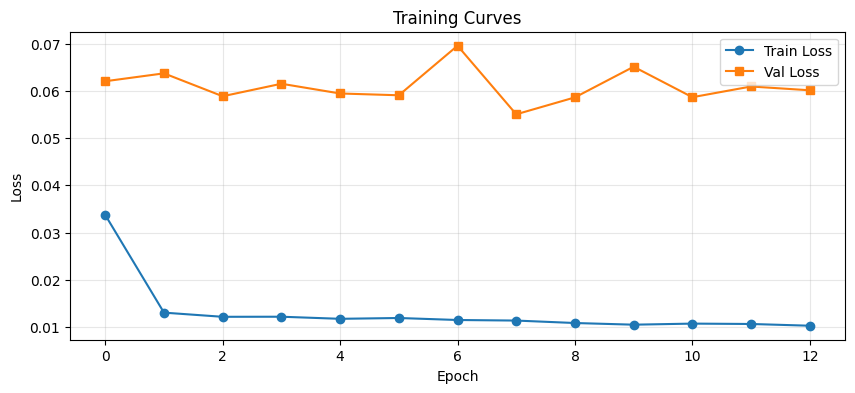

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 9: TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════════
# Training với mixed precision và gradient clipping

model = TwoTowerRecommender(
    n_users=n_users,
    n_products=n_products,
    text_embedding_dim=embedding_dim,
    embedding_dim=64,
    hidden_dim=128,
    temperature=0.07
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
criterion = nn.BCEWithLogitsLoss()
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

# Product embeddings index mapping
product_idx_to_embedding = {}
for idx, (pid, emb) in enumerate(product_id_to_embedding.items()):
    try:
        encoded_idx = product_encoder.transform([pid])[0]
        product_idx_to_embedding[encoded_idx] = emb
    except:
        pass

def get_batch_text_embeddings(product_indices):
    """Lấy text embeddings cho batch products"""
    batch_embs = []
    for idx in product_indices.cpu().numpy():
        if idx in product_idx_to_embedding:
            batch_embs.append(product_idx_to_embedding[idx])
        else:
            batch_embs.append(np.zeros(embedding_dim))
    return torch.tensor(np.array(batch_embs), dtype=torch.float32).to(device)

print("\n🚀 Starting training...")
print(f"   Model parameters: {sum(p.numel() for p in model.parameters()):,}")

best_val_loss = float('inf')
train_losses = []
val_losses = []
patience = 5
patience_counter = 0

NUM_EPOCHS = 30

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        user_idx = batch['user_idx'].to(device)
        product_idx = batch['product_idx'].to(device)
        label = batch['label'].to(device)

        text_emb = get_batch_text_embeddings(product_idx)

        optimizer.zero_grad()

        if scaler:
            with torch.cuda.amp.autocast():
                pred = model(user_idx, product_idx, text_emb)
                loss = criterion(pred, label)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(user_idx, product_idx, text_emb)
            loss = criterion(pred, label)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            user_idx = batch['user_idx'].to(device)
            product_idx = batch['product_idx'].to(device)
            label = batch['label'].to(device)

            text_emb = get_batch_text_embeddings(product_idx)
            pred = model(user_idx, product_idx, text_emb)
            loss = criterion(pred, label)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step()

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, LR = {scheduler.get_last_lr()[0]:.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
        print(f"   ✅ Saved best model!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"   ⏹️ Early stopping at epoch {epoch+1}")
            break

# Plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Curves')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 10: PRECOMPUTE RECOMMENDATIONS
# ══════════════════════════════════════════════════════════════════════════════
# Tính sẵn recommendations cho tất cả users

model.load_state_dict(torch.load('best_model.pt'))
model.eval()

print("\n📊 Precomputing product embeddings...")
all_product_indices = torch.arange(n_products).to(device)
all_text_embs = torch.zeros(n_products, embedding_dim).to(device)
for idx in range(n_products):
    if idx in product_idx_to_embedding:
        all_text_embs[idx] = torch.tensor(product_idx_to_embedding[idx])

with torch.no_grad():
    all_product_vecs = model.get_product_embedding(all_product_indices, all_text_embs)

print("\n👥 Precomputing recommendations for all users...")
precomputed_recs = {}
TOP_K = 50

for user_idx in tqdm(range(n_users)):
    user_tensor = torch.tensor([user_idx]).to(device)

    with torch.no_grad():
        user_vec = model.get_user_embedding(user_tensor)

        # Cosine similarity
        similarities = torch.matmul(user_vec, all_product_vecs.T).squeeze()

        # Get top K
        top_indices = torch.argsort(similarities, descending=True)[:TOP_K]
        top_product_indices = top_indices.cpu().numpy().tolist()

        # Convert back to product_id
        top_product_ids = product_encoder.inverse_transform(top_product_indices).tolist()

        # Get original user_id
        user_id = int(user_encoder.inverse_transform([user_idx])[0])
        precomputed_recs[user_id] = [int(pid) for pid in top_product_ids]

print(f"✅ Computed recommendations for {len(precomputed_recs)} users")


📊 Precomputing product embeddings...

👥 Precomputing recommendations for all users...


  0%|          | 0/72 [00:00<?, ?it/s]

✅ Computed recommendations for 72 users


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 11: SIMILAR PRODUCTS MATRIX
# ══════════════════════════════════════════════════════════════════════════════
# Tính sẵn sản phẩm tương tự

print("\n🔗 Computing similar products...")
similar_products = {}

with torch.no_grad():
    product_similarity = torch.matmul(all_product_vecs, all_product_vecs.T)

    for product_idx in tqdm(range(n_products)):
        similarities = product_similarity[product_idx].clone()
        similarities[product_idx] = -1  # Exclude self

        top_indices = torch.argsort(similarities, descending=True)[:20]
        top_product_indices = top_indices.cpu().numpy().tolist()

        product_id = int(product_encoder.inverse_transform([product_idx])[0])
        similar_ids = product_encoder.inverse_transform(top_product_indices).tolist()
        similar_products[product_id] = [int(pid) for pid in similar_ids]

print(f"✅ Computed similar products for {len(similar_products)} products")


🔗 Computing similar products...


  0%|          | 0/483 [00:00<?, ?it/s]

✅ Computed similar products for 483 products


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 12: EXPORT KẾT QUẢ
# ══════════════════════════════════════════════════════════════════════════════
# Export files để deploy vào Spring Boot

os.makedirs('model_output', exist_ok=True)

# 1. Precomputed recommendations
with open('model_output/precomputed_recs.json', 'w', encoding='utf-8') as f:
    json.dump(precomputed_recs, f, ensure_ascii=False)
print(f"✅ Saved precomputed_recs.json ({len(precomputed_recs)} users)")

# 2. Similar products
with open('model_output/similar_products.json', 'w', encoding='utf-8') as f:
    json.dump(similar_products, f, ensure_ascii=False)
print(f"✅ Saved similar_products.json ({len(similar_products)} products)")

# 3. Product embeddings (for real-time user embedding calculation)
product_embeddings_export = {}
for idx in range(n_products):
    pid = int(product_encoder.inverse_transform([idx])[0])
    emb = all_product_vecs[idx].cpu().numpy().tolist()
    product_embeddings_export[str(pid)] = emb

with open('model_output/product_embeddings.json', 'w', encoding='utf-8') as f:
    json.dump(product_embeddings_export, f, ensure_ascii=False)
print(f"✅ Saved product_embeddings.json ({len(product_embeddings_export)} products)")

# 4. Encoders
with open('model_output/user_encoder.pkl', 'wb') as f:
    pickle.dump(user_encoder, f)
with open('model_output/product_encoder.pkl', 'wb') as f:
    pickle.dump(product_encoder, f)
print("✅ Saved encoders")

# 5. Model weights
torch.save(model.state_dict(), 'model_output/two_tower_model.pt')
print("✅ Saved model weights")

# 6. Config
config = {
    'n_users': n_users,
    'n_products': n_products,
    'embedding_dim': 64,
    'hidden_dim': 128,
    'text_embedding_dim': embedding_dim,
    'temperature': 0.07,
    'top_k': TOP_K,
    'model_name': 'paraphrase-multilingual-MiniLM-L12-v2',
    'trained_at': datetime.now().isoformat()
}
with open('model_output/config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✅ Saved config.json")

# 7. Elasticsearch documents (with embeddings)
print("\n📤 Creating Elasticsearch documents...")
es_documents = []
for idx in range(n_products):
    pid = int(product_encoder.inverse_transform([idx])[0])
    emb = all_product_vecs[idx].cpu().numpy().tolist()

    # Find product info
    product_info = products_df[products_df['product_id'] == pid].iloc[0] if len(products_df[products_df['product_id'] == pid]) > 0 else {}

    doc = {
        "product_id": pid,
        "name": product_info.get('name', f'Product {pid}') if isinstance(product_info, dict) else (product_info['name'] if 'name' in product_info else f'Product {pid}'),
        "embedding": emb
    }

    if isinstance(product_info, pd.Series):
        if 'category_id' in product_info:
            doc['category_id'] = int(product_info['category_id']) if pd.notna(product_info['category_id']) else None
        if 'shop_id' in product_info:
            doc['shop_id'] = int(product_info['shop_id']) if pd.notna(product_info['shop_id']) else None
        if 'rating' in product_info:
            doc['rating'] = float(product_info['rating']) if pd.notna(product_info['rating']) else 0

    es_documents.append(doc)

with open('model_output/es_documents.json', 'w', encoding='utf-8') as f:
    json.dump(es_documents, f, ensure_ascii=False)
print(f"✅ Saved es_documents.json ({len(es_documents)} documents)")

✅ Saved precomputed_recs.json (72 users)
✅ Saved similar_products.json (483 products)
✅ Saved product_embeddings.json (483 products)
✅ Saved encoders
✅ Saved model weights
✅ Saved config.json

📤 Creating Elasticsearch documents...
✅ Saved es_documents.json (483 documents)


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 13: ZIP VÀ DOWNLOAD
# ══════════════════════════════════════════════════════════════════════════════

!cd model_output && zip -r ../model_output.zip .
files.download('model_output.zip')

print("\n" + "="*70)
print("🎉 HOÀN TẤT!")
print("="*70)
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                         📁 MODEL OUTPUT FILES                                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  precomputed_recs.json      → Recommendations cho mỗi user (fallback)        ║
║  similar_products.json      → Sản phẩm tương tự (precomputed)                ║
║  product_embeddings.json    → Embeddings để tính user vector real-time       ║
║  es_documents.json          → Documents để index vào Elasticsearch           ║
║  two_tower_model.pt         → Model weights (cho future updates)             ║
║  config.json                → Config (embedding_dim, trained_at, etc)        ║
║  user_encoder.pkl           → Encoder cho user IDs                           ║
║  product_encoder.pkl        → Encoder cho product IDs                        ║
╚══════════════════════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════════════════════╗
║                    📋 HƯỚNG DẪN DEPLOY CHI TIẾT                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  BƯỚC 1: Giải nén model_output.zip                                           ║
║  ────────────────────────────────────────────────────────────────────────    ║
║  Giải nén vào folder:                                                        ║
║  FoodTourApp/src/main/resources/models/content/model_output/                 ║
║                                                                              ║
║  BƯỚC 2: Sync embeddings vào Elasticsearch                                   ║
║  ────────────────────────────────────────────────────────────────────────    ║
║  cd FoodTourApp/scripts/recommend                                            ║
║  python sync_es_rcm_behavior.py                                              ║
║                                                                              ║
║  Script sẽ:                                                                  ║
║  - Đọc config.json để lấy embedding dimension (64)                           ║
║  - Xóa index cũ, tạo index mới với mapping đúng                              ║
║  - Index tất cả products từ es_documents.json                                ║
║  - Verify KNN search hoạt động                                               ║
║                                                                              ║
║  BƯỚC 3: Restart Spring Boot                                                 ║
║  ────────────────────────────────────────────────────────────────────────    ║
║  RealTimeRecommendationServiceImpl sẽ:                                       ║
║  - Load product_embeddings.json khi khởi động                                ║
║  - Tự động detect embedding dimension từ file                                ║
║  - Sẵn sàng nhận track behaviors và tính real-time recommendations          ║
║                                                                              ║
║  BƯỚC 4: Test APIs                                                           ║
║  ────────────────────────────────────────────────────────────────────────    ║
║                                                                              ║
║  # Get real-time recommendations (cần auth token)                            ║
║  GET /api/user/recommendations/for-you?limit=10                              ║
║                                                                              ║
║  # Get similar products (public)                                             ║
║  GET /api/user/recommendations/similar/123?limit=5                           ║
║                                                                              ║
║  # Track user behavior (gọi từ frontend khi user tương tác)                  ║
║  POST /api/user/recommendations/track                                        ║
║  {                                                                           ║
║    "productId": 123,                                                         ║
║    "actionType": "VIEW",     // VIEW, CLICK, ADD_CART, PURCHASE, etc         ║
║    "sessionId": "abc123",                                                    ║
║    "source": "RECOMMENDATION",  // SEARCH, RECOMMENDATION, CATEGORY, DIRECT ║
║    "viewDurationSeconds": 30    // optional, for VIEW action                 ║
║  }                                                                           ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════════════════════╗
║                    🔄 REAL-TIME UPDATE FLOW                                   ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. User browses/clicks/buys product                                         ║
║       ↓                                                                      ║
║  2. Frontend gọi POST /track với action info                                 ║
║       ↓                                                                      ║
║  3. Backend lưu behavior vào DB + async update user embedding                ║
║       ↓                                                                      ║
║  4. User embedding = weighted average của product embeddings                 ║
║       ↓                                                                      ║
║  5. Cache user embedding trong Redis (TTL 6 hours)                           ║
║       ↓                                                                      ║
║  6. Next request: dùng cached embedding → ES KNN search                      ║
║       ↓                                                                      ║
║  7. Trả về sản phẩm gần nhất với user embedding                              ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════════════════════╗
║                    ⚠️ LƯU Ý QUAN TRỌNG                                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. Elasticsearch phải đang chạy trước khi chạy sync script                  ║
║     docker-compose up -d elasticsearch                                       ║
║                                                                              ║
║  2. Redis phải đang chạy để cache user embeddings                            ║
║     docker-compose up -d redis                                               ║
║                                                                              ║
║  3. Nếu không có behaviors, system sẽ fallback:                              ║
║     - Collaborative filtering từ similar users                               ║
║     - Top rated products                                                     ║
║                                                                              ║
║  4. Re-train khi cần:                                                        ║
║     - Chạy lại notebook này với data mới                                     ║
║     - Export training data: GET /api/public/recommendation/training-data     ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

  adding: precomputed_recs.json (deflated 72%)
  adding: es_documents.json (deflated 59%)
  adding: user_encoder.pkl (deflated 57%)
  adding: product_encoder.pkl (deflated 75%)
  adding: config.json (deflated 32%)
  adding: two_tower_model.pt (deflated 9%)
  adding: product_embeddings.json (deflated 57%)
  adding: similar_products.json (deflated 70%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 HOÀN TẤT!

╔══════════════════════════════════════════════════════════════════════════════╗
║                         📁 MODEL OUTPUT FILES                                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  precomputed_recs.json      → Recommendations cho mỗi user (fallback)        ║
║  similar_products.json      → Sản phẩm tương tự (precomputed)                ║
║  product_embeddings.json    → Embeddings để tính user vector real-time       ║
║  es_documents.json          → Documents để index vào Elasticsearch           ║
║  two_tower_model.pt         → Model weights (cho future updates)             ║
║  config.json                → Config (embedding_dim, trained_at, etc)        ║
║  user_encoder.pkl           → Encoder cho user IDs                           ║
║  product_encoder.pkl        → Encoder cho product IDs                        ║
╚══════════════════════════════════════════════════════════════════════════════╝

╔════════════